In [1]:
#  ONE CLICK RUN (FINAL)

import joblib
import pandas as pd

# load everything
model = joblib.load("final_model.pkl")
X_test, y_test = joblib.load("test_data.pkl")
feature_names = joblib.load("features.pkl")

print(" Model & Data Loaded Successfully")

 Model & Data Loaded Successfully


In [2]:
# 1. IMPORTS

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import joblib


In [91]:
# 2. LOAD DATA (CSV)

base_path = r"C:\Users\PRAKHAR BAJPAI\Downloads\MachineLearningCSV\MachineLearningCVE"

mon = pd.read_csv(base_path + r"\Monday-WorkingHours.pcap_ISCX.csv")

tue = pd.read_csv(base_path + r"\Tuesday-WorkingHours.pcap_ISCX.csv")

wed = pd.read_csv(base_path + r"\Wednesday-workingHours.pcap_ISCX.csv")

thu1 = pd.read_csv(base_path + r"\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
thu2 = pd.read_csv(base_path + r"\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")

fri1 = pd.read_csv(base_path + r"\Friday-WorkingHours-Morning.pcap_ISCX.csv")
fri2 = pd.read_csv(base_path + r"\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
fri3 = pd.read_csv(base_path + r"\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

In [92]:
# 3. MERGE DATASETS

df = pd.concat([mon, tue, wed, thu1, thu2, fri1, fri2, fri3], ignore_index=True)

In [93]:
# 4. CLEAN + PREPROCESS

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.dropna(inplace=True)

In [94]:
#5 FINAL FIX: CLEAN 

# remove spaces (safe)
df.columns = df.columns.str.strip()

# confirm label exists
print("Columns OK:", 'Label' in df.columns)



Columns OK: True


In [95]:
#6 FIXED: FEATURES + TARGET (FINAL CLEAN)
# 6. FEATURES + TARGET (FIXED)

X = df.drop('Label', axis=1)
X = X.select_dtypes(include=[np.number])

y = df['Label']

In [96]:
# 6.1 REMOVE HIGH CORRELATED FEATURES

import pandas as pd
import numpy as np

corr = pd.DataFrame(X).corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

X = pd.DataFrame(X).drop(columns=to_drop)

In [97]:
#7 FIXED: STRATIFIED SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [98]:
#8 FIXED: REDUCE OVERFITTING

model = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

In [99]:
##9 TRAIN MODEL (ADD THIS)

#9 FIX: TRAIN MODEL

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [88]:
# SAVE MODEL (ONE TIME)

joblib.dump(model, "rf_model_multiclass.pkl")

['rf_model_multiclass.pkl']

In [72]:
# 9. SAVE MODEL

joblib.dump(model, "rf_model.pkl")

['rf_model.pkl']

In [73]:
import os
print(os.listdir())

[' ids practice.ipynb', '-1.14-windows.xml', '.bash_history', '.cache', '.claude', '.claude.json', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.matplotlib', '.ollama', '.openshot_qt', '.vscode', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'features.pkl', 'final_data.pkl', 'final_data_clean.pkl', 'final_level.ipynb', 'final_model.pkl', 'ids final.ipynb', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'model.pkl', 'Monday-WorkingHours.pcap_ISCX.csv', 'Music', 'My Documents', 'NetHood', 'nltk.ipynb', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{b08c70b8-abd0-11ef-83ca-cfefa0f590d8}.TM.blf', 'NTUSER.DAT{b08c70b8-abd0-11ef-83ca-cfefa0f590d8}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{b08c70b8-abd0-11ef-83ca-cfefa0f590d8}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Oracle', 'Pictures', 'PrintHood', 'project file', 'Rave.dat', 'Recent', 'rf_model.pkl', '

In [100]:
# 11. PREDICT

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                            precision    recall  f1-score   support

                    BENIGN       1.00      0.96      0.98    454265
                       Bot       0.05      1.00      0.09       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       0.81      0.99      0.89      2059
                  DoS Hulk       0.92      1.00      0.96     46025
          DoS Slowhttptest       0.94      0.99      0.96      1100
             DoS slowloris       0.98      0.99      0.99      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       0.67      1.00      0.80         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.99      1.00      1.00     31761
               SSH-Patator       0.81      1.00      0.90      1180
  Web Attack � Brute Force       0.19      0.52      0.28       301
Web Attack � Sql Injection       0.00      0.75

In [101]:
print(y.unique())

<StringArray>
[                    'BENIGN',                'FTP-Patator',
                'SSH-Patator',              'DoS slowloris',
           'DoS Slowhttptest',                   'DoS Hulk',
              'DoS GoldenEye',                 'Heartbleed',
   'Web Attack � Brute Force',           'Web Attack � XSS',
 'Web Attack � Sql Injection',               'Infiltration',
                        'Bot',                   'PortScan',
                       'DDoS']
Length: 15, dtype: str


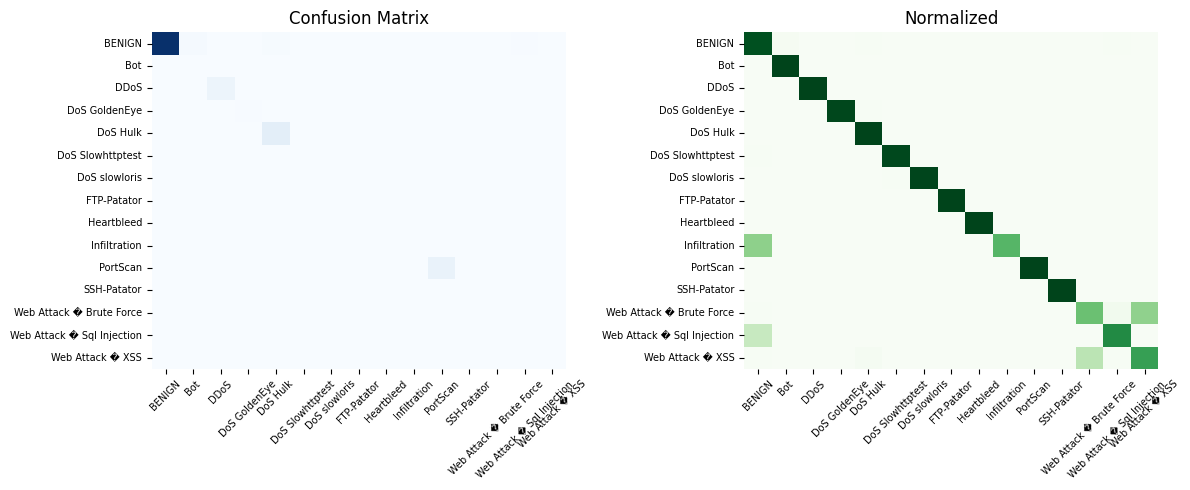

In [121]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = np.unique(y_test)

# normalize
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,5))   # 👈 single image में 2 graph

# 🔹 LEFT: ORIGINAL
plt.subplot(1,2,1)
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title("Confusion Matrix")
plt.xticks(rotation=45, fontsize=7)
plt.yticks(rotation=0, fontsize=7)

# 🔹 RIGHT: NORMALIZED
plt.subplot(1,2,2)
sns.heatmap(
    cm_norm,
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title("Normalized")
plt.xticks(rotation=45, fontsize=7)
plt.yticks(rotation=0, fontsize=7)

plt.tight_layout()
plt.show()

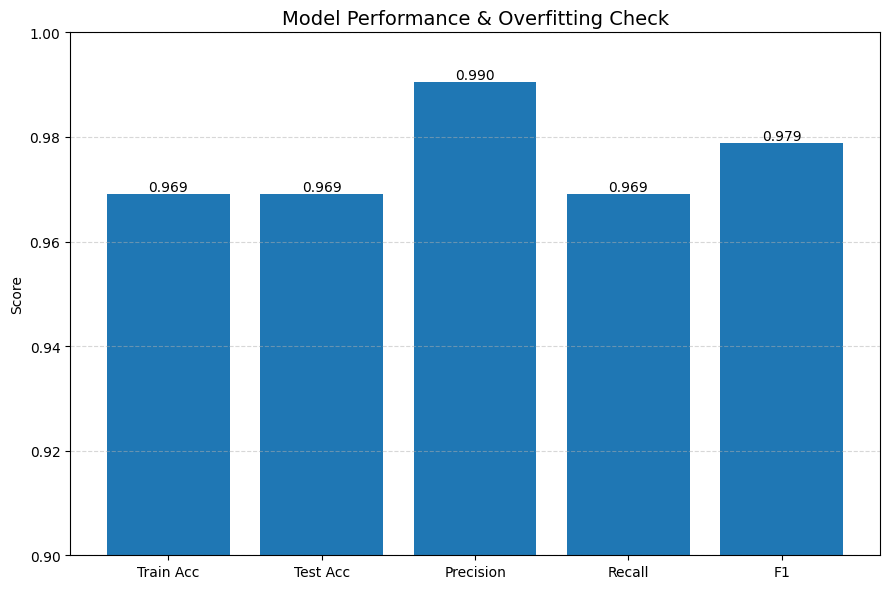

In [124]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# 🔥 IMPORTANT ADDITION
train_acc = model.score(X_train, y_train)

labels = ["Train Acc", "Test Acc", "Precision", "Recall", "F1"]
values = [train_acc, acc, prec, rec, f1]

plt.figure(figsize=(9,6))

bars = plt.bar(labels, values)

# values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.3f}", ha='center', va='bottom', fontsize=10)

plt.title("Model Performance & Overfitting Check", fontsize=14)
plt.ylabel("Score")
plt.ylim(0.9, 1.0)   # 👈 zoom effect (IMPORTANT)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

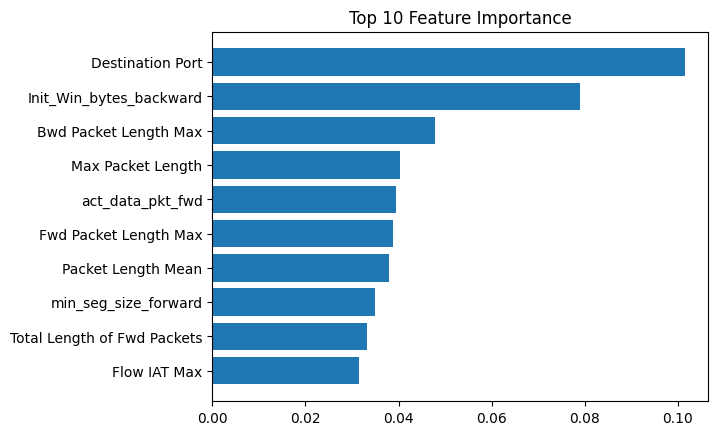

In [115]:
#14 FEATURE IMPORTANCE

import pandas as pd

importances = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# top 10
top_feat = feat_df.head(10)

plt.figure()
plt.barh(top_feat["Feature"], top_feat["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()


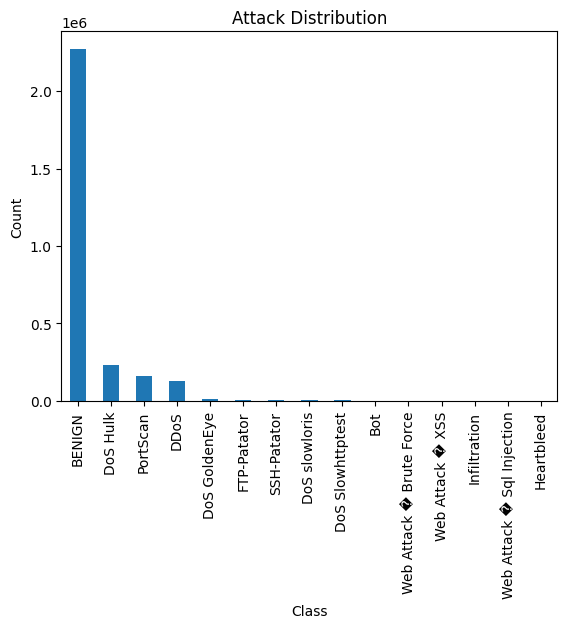

In [107]:
#15 ATTACK DISTRIBUTION

plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Attack Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

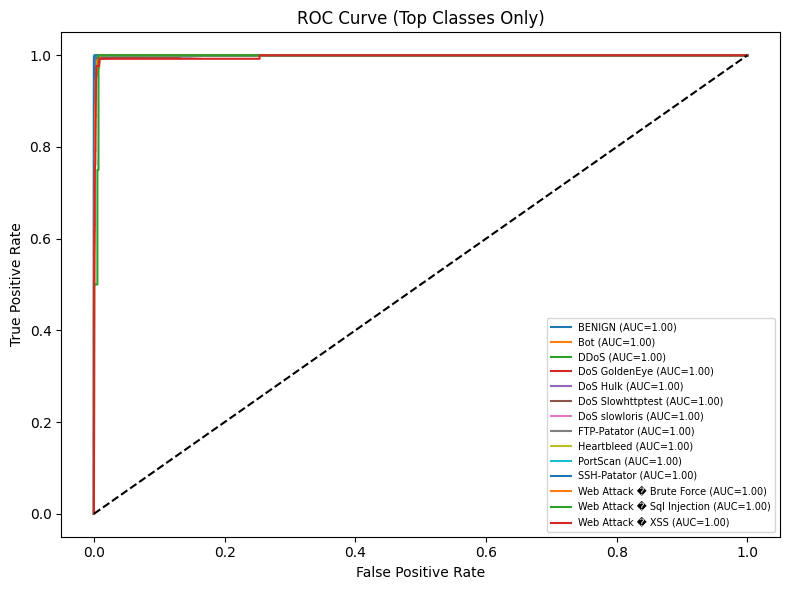

In [125]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

y_score = model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    # 👇 only show important classes
    if roc_auc > 0.95:
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Top Classes Only)")
plt.legend(fontsize=7)

plt.tight_layout()
plt.show()

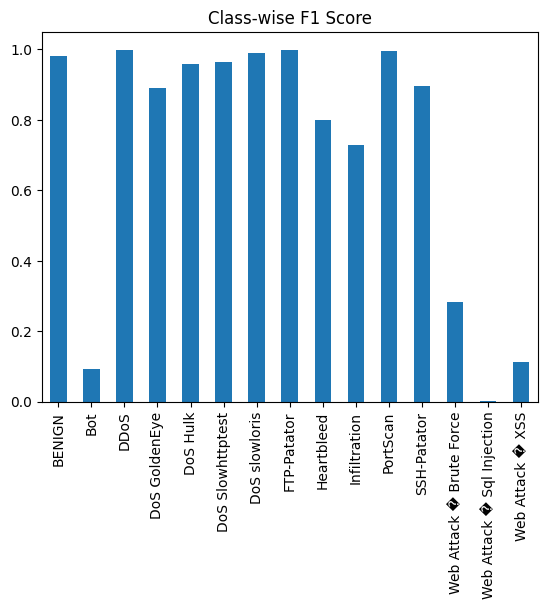

In [117]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report['f1-score'][:-3].plot(kind='bar')
plt.title("Class-wise F1 Score")
plt.show()

In [39]:
# 12. OLLAMA SETUP

import requests

In [40]:
# 13. LLM EXPLANATION (ADVANCED)

def llm_explain(sample):
    pred = model.predict(sample)[0]

    prompt = f"""
    You are a senior cybersecurity analyst.

    The IDS detected attack type: {pred}

    Provide:
    1. Detailed explanation of this attack
    2. How attackers perform it
    3. Risk level (Low/Medium/High)
    4. Real-world impact
    5. Prevention and mitigation steps
    """

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3",
            "prompt": prompt,
            "stream": False
        }
    )

    print(response.json()["response"])

In [41]:
# 14. TEST

sample = X_test.iloc[[0]]
llm_explain(sample)

**Attack: BENIGN**

**Detailed Explanation:**
A BENIGN attack, also known as a "benign anomaly," is a type of network traffic that is identified by an Intrusion Detection System (IDS) as unusual or suspicious, but ultimately harmless to the target system. This type of traffic may not conform to typical patterns or protocols, causing the IDS to flag it for further investigation.

**How Attackers Perform It:**
In most cases, BENIGN attacks are not intentionally launched by malicious actors. Instead, they often result from legitimate network activity that is misinterpreted by the IDS as malicious. This can occur due to various factors, such as:

1. Misconfigured networks or devices
2. Unusual traffic patterns caused by new applications or services
3. Legitimate usage of protocols or tools that are not commonly seen in normal network traffic

**Risk Level:**
Low

**Real-world Impact:**
While BENIGN attacks may trigger false positives, they do not pose a significant risk to the target syste

In [44]:
import shap

C:\Users\PRAKHAR BAJPAI\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
explainer = shap.TreeExplainer(model)

In [47]:
sample = X_test.iloc[[0]]
shap_values = explainer.shap_values(sample)

In [50]:
# REMOVE NaN (IMPORTANT FOR SHAP)

sample_data = sample_data.fillna(0)

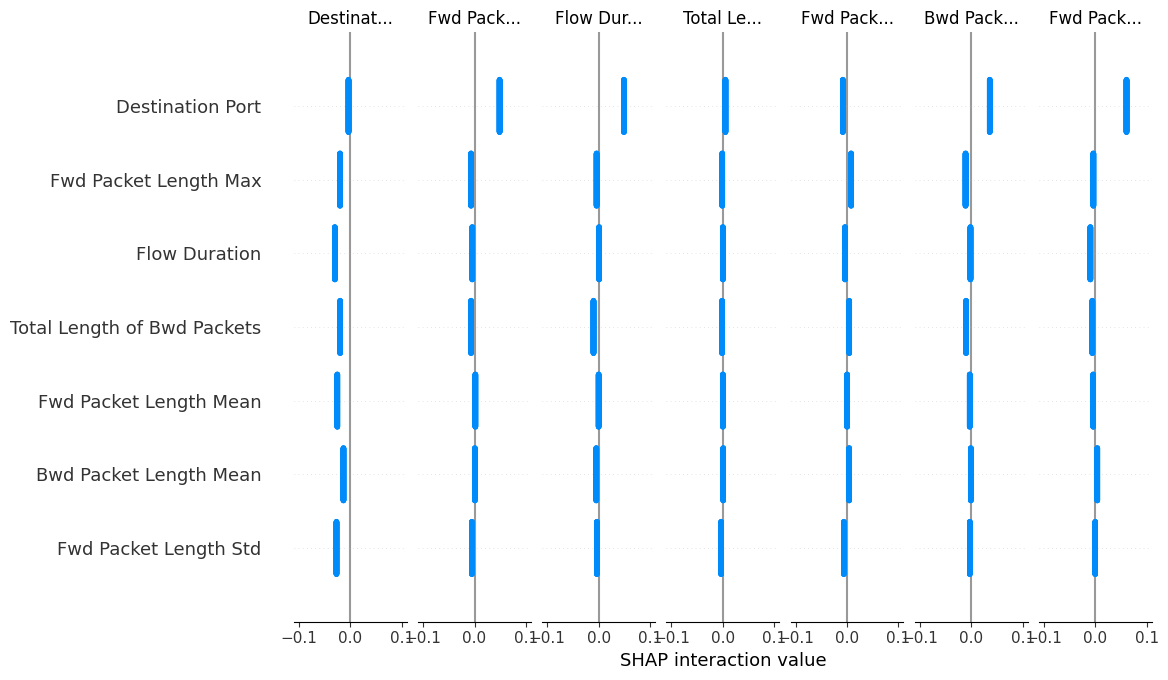

In [51]:
# 14. SHAP (FINAL)
import shap
import pandas as pd

sample_data = pd.DataFrame(X_test[:300], columns=feature_names)

# 🔥 FIX
sample_data = sample_data.fillna(0)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample_data)

shap.summary_plot(shap_values, sample_data)

In [31]:
# FINAL SAVE (MODEL + DATA + FEATURES)

joblib.dump(model, "final_model.pkl")
joblib.dump((X_test, y_test), "test_data.pkl")
joblib.dump(feature_names, "features.pkl")

['features.pkl']

In [109]:
# PREDICT

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                            precision    recall  f1-score   support

                    BENIGN       1.00      0.96      0.98    454265
                       Bot       0.05      1.00      0.09       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       0.81      0.99      0.89      2059
                  DoS Hulk       0.92      1.00      0.96     46025
          DoS Slowhttptest       0.94      0.99      0.96      1100
             DoS slowloris       0.98      0.99      0.99      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       0.67      1.00      0.80         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.99      1.00      1.00     31761
               SSH-Patator       0.81      1.00      0.90      1180
  Web Attack � Brute Force       0.19      0.52      0.28       301
Web Attack � Sql Injection       0.00      0.75